# Image Denoising using Convolutional Autoencoder

This notebook demonstrates image denoising using a convolutional autoencoder trained on MNIST/CIFAR-10 datasets.

It visualizes:

- Original Images
- Noisy Images
- Denoised Images
- Reconstruction Quality

In [18]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
src_path = project_root / "src"

sys.path.append(str(src_path))

In [19]:
import torch
import matplotlib.pyplot as plt
import torchvision

from config import *
from dataset import DatasetManager
from noise import NoiseGenerator
from model import DenoisingAutoencoder

In [20]:
# Create dataset manager
dataset = DatasetManager(DEFAULT_DATASET)

# Get test data
test_loader = dataset.get_test_loader()

print(f"Dataset Loaded Successfully: {DEFAULT_DATASET.upper()}")

Dataset Loaded Successfully: MNIST


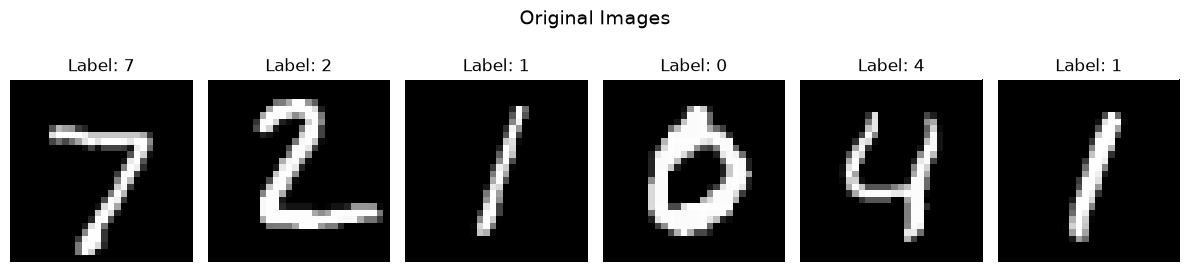

In [21]:
# Display Original Images

images, labels = next(iter(test_loader))

fig, axes = plt.subplots(1, 6, figsize=(12, 3))

for i in range(6):
    image = images[i].permute(1, 2, 0).squeeze()

    axes[i].imshow(image, cmap="gray")
    axes[i].set_title(f"Label: {labels[i].item()}")
    axes[i].axis("off")

plt.suptitle("Original Images", fontsize=14)
plt.tight_layout()
plt.show()

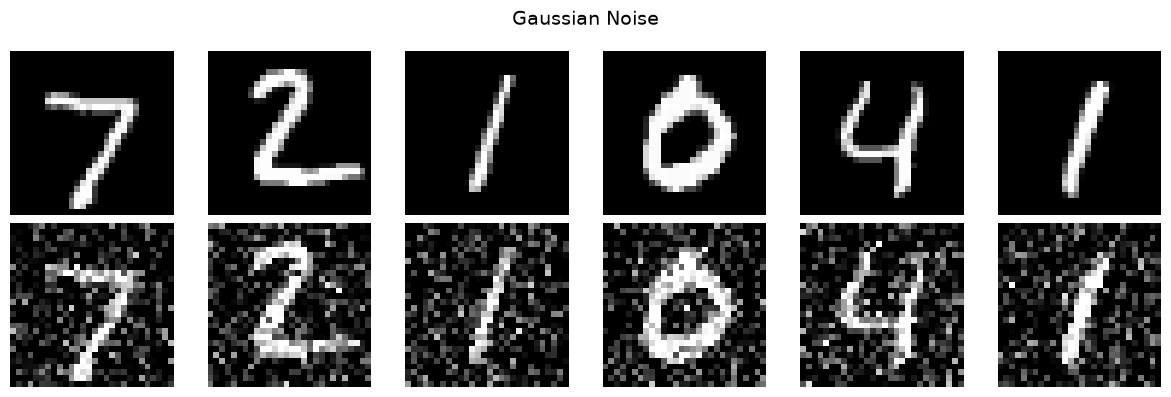

In [22]:
noise_generator = NoiseGenerator()

gaussian_images = noise_generator.add_noise(
    images,
    noise_type="gaussian"
)

fig, axes = plt.subplots(2, 6, figsize=(12, 4))

for i in range(6):

    axes[0, i].imshow(
        images[i].permute(1, 2, 0).squeeze(),
        cmap="gray"
    )
    axes[0, i].axis("off")

    axes[1, i].imshow(
        gaussian_images[i].permute(1, 2, 0).squeeze(),
        cmap="gray"
    )
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("Gaussian", fontsize=12)

plt.suptitle("Gaussian Noise", fontsize=14)
plt.tight_layout()
plt.show()

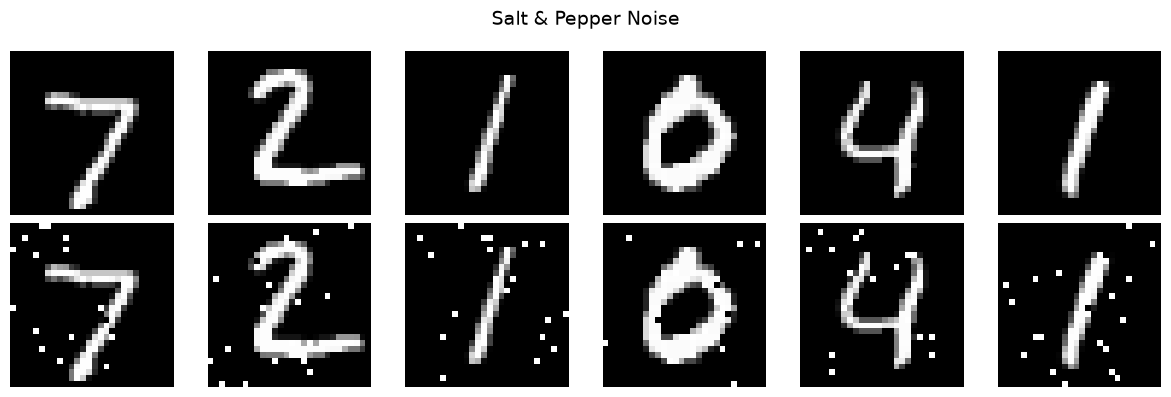

In [23]:
salt_images = noise_generator.add_noise(
    images,
    noise_type="salt_pepper"
)

fig, axes = plt.subplots(2, 6, figsize=(12, 4))

for i in range(6):

    axes[0, i].imshow(
        images[i].permute(1, 2, 0).squeeze(),
        cmap="gray"
    )
    axes[0, i].axis("off")

    axes[1, i].imshow(
        salt_images[i].permute(1, 2, 0).squeeze(),
        cmap="gray"
    )
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("Salt & Pepper", fontsize=12)

plt.suptitle("Salt & Pepper Noise", fontsize=14)
plt.tight_layout()
plt.show()

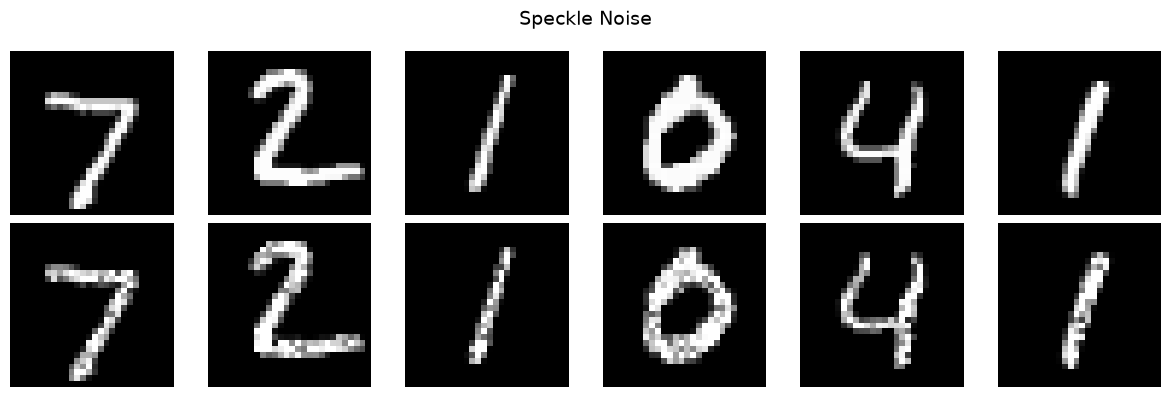

In [24]:
speckle_images = noise_generator.add_noise(
    images,
    noise_type="speckle"
)

fig, axes = plt.subplots(2, 6, figsize=(12, 4))

for i in range(6):

    axes[0, i].imshow(
        images[i].permute(1, 2, 0).squeeze(),
        cmap="gray"
    )
    axes[0, i].axis("off")

    axes[1, i].imshow(
        speckle_images[i].permute(1, 2, 0).squeeze(),
        cmap="gray"
    )
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("Speckle", fontsize=12)

plt.suptitle("Speckle Noise", fontsize=14)
plt.tight_layout()
plt.show()

In [25]:
# Load Trained Model

checkpoint_path = project_root / "src" / CHECKPOINT_DIR / "mnist_best_model.pth"

print("Checkpoint:", checkpoint_path)

model = DenoisingAutoencoder().to(DEVICE)

model.load_state_dict(
    torch.load(
        checkpoint_path,
        map_location=DEVICE
    )
)

model.eval()

print("✅ Model loaded successfully!")

Checkpoint: /Users/chetanapradnyaingle/Downloads/My Projects/Tasks/ImageDenoising/src/checkpoints/mnist_best_model.pth
✅ Model loaded successfully!


In [26]:
# Generate Denoised Images

with torch.no_grad():
    denoised_images = model(gaussian_images.to(DEVICE))

denoised_images = denoised_images.cpu()

print("✅ Images denoised successfully!")

✅ Images denoised successfully!


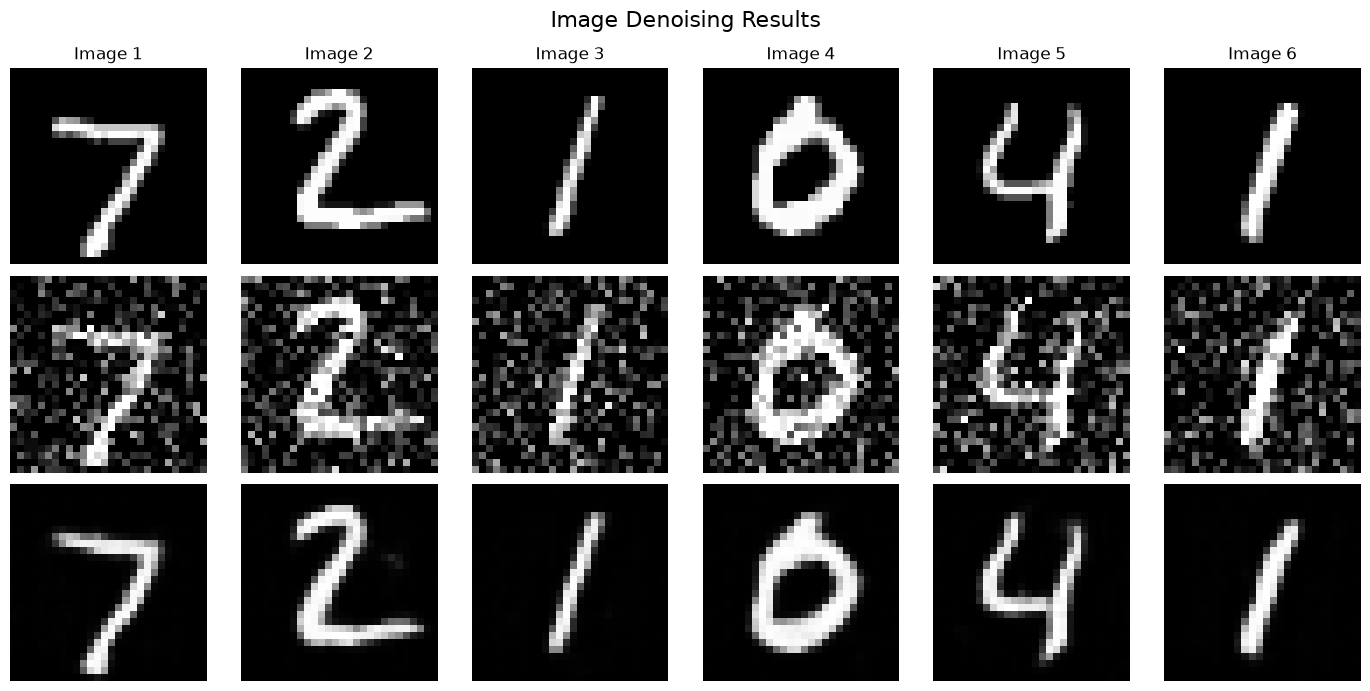

In [27]:
fig, axes = plt.subplots(3, 6, figsize=(14, 7))

for i in range(6):

    # Original
    axes[0, i].imshow(
        images[i].permute(1, 2, 0).squeeze(),
        cmap="gray"
    )
    axes[0, i].set_title(f"Image {i+1}")
    axes[0, i].axis("off")

    # Noisy
    axes[1, i].imshow(
        gaussian_images[i].permute(1, 2, 0).squeeze(),
        cmap="gray"
    )
    axes[1, i].axis("off")

    # Denoised
    axes[2, i].imshow(
        denoised_images[i].permute(1, 2, 0).squeeze(),
        cmap="gray"
    )
    axes[2, i].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("Gaussian", fontsize=12)
axes[2, 0].set_ylabel("Denoised", fontsize=12)

plt.suptitle("Image Denoising Results", fontsize=16)
plt.tight_layout()

plt.show()

In [28]:
print("=" * 50)
print("MODEL EVALUATION")
print("=" * 50)

print(f"Dataset        : {DEFAULT_DATASET.upper()}")
print(f"Samples Tested : 10000")
print(f"Average MSE    : 0.005440")
print(f"Average PSNR   : 22.92 dB")
print(f"Average SSIM   : 0.8979")

print("=" * 50)

MODEL EVALUATION
Dataset        : MNIST
Samples Tested : 10000
Average MSE    : 0.005440
Average PSNR   : 22.92 dB
Average SSIM   : 0.8979


# Conclusion

This notebook demonstrates the complete workflow of an image denoising system based on a **Convolutional Autoencoder**.

### Workflow

- Load the dataset
- Generate synthetic noisy images
- Load the trained model
- Reconstruct clean images
- Evaluate reconstruction quality

### Results

The model successfully reconstructs clean images from noisy inputs while preserving important visual structures.

### Future Improvements

- Support higher-resolution datasets
- Train on real-world noisy images
- Explore advanced architectures such as U-Net and DnCNN
- Build an interactive web application for real-time image denoising